In [1]:
import sympy as sym
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys
from tqdm.auto import tqdm
import warnings

sys.path.append( '../src' )
from GaussianQFINumerics import FIM, vectorized_QFIM#,SLD,_SLD_precomp,FIE
#%matplotlib widget

In [2]:
r,nbar, η1,η2,α, r2 = sym.symbols('r nbar eta1 eta2 alpha r2')

In [3]:
σ0 = np.matrix([
        [1+2*sym.sinh(r)**2,0,0,0,-2*sym.sinh(r)*sym.cosh(r),0 ],
        [0,1+2*sym.sinh(r)**2,0,0,0,2*sym.sinh(r)*sym.cosh(r)],
        [0,0,1,0,0,0],
        [0,0,0,1,0,0],
        [-2*sym.sinh(r)*sym.cosh(r),0,0,0,1+2*sym.sinh(r)**2,0],
        [0,2*sym.sinh(r)*sym.cosh(r),0,0,0, 1+2*sym.sinh(r)**2]
    ])

In [4]:
print(σ0)

[[2*sinh(r)**2 + 1 0 0 0 -2*sinh(r)*cosh(r) 0]
 [0 2*sinh(r)**2 + 1 0 0 0 2*sinh(r)*cosh(r)]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [-2*sinh(r)*cosh(r) 0 0 0 2*sinh(r)**2 + 1 0]
 [0 2*sinh(r)*cosh(r) 0 0 0 2*sinh(r)**2 + 1]]


In [5]:
X1 = np.matrix([
        [α,0,sym.sqrt(1-α**2),0,0,0],
        [0,α,0,sym.sqrt(1-α**2),0,0],
        [-sym.sqrt(1-α**2),0,α,0,0,0],
        [0,-sym.sqrt(1-α**2),0,α,0,0],
        [0,0,0,0,1,0],
        [0,0,0,0,0,1]
    ])

In [6]:
print(X1)

[[alpha 0 sqrt(1 - alpha**2) 0 0 0]
 [0 alpha 0 sqrt(1 - alpha**2) 0 0]
 [-sqrt(1 - alpha**2) 0 alpha 0 0 0]
 [0 -sqrt(1 - alpha**2) 0 alpha 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]


In [7]:
X2 = np.matrix([
        [1,0,0,0,0,0],
        [0,1,0,0,0,0],
        [0,0,sym.cosh(r2),0,sym.sinh(r2),0],
        [0,0,0,sym.cosh(r2),0,-sym.sinh(r2)],
        [0,0,sym.sinh(r2),0,sym.cosh(r2),0],
        [0,0,0,-sym.sinh(r2),0,sym.cosh(r2)]
    ])

In [8]:
X2

matrix([[1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, cosh(r2), 0, sinh(r2), 0],
        [0, 0, 0, cosh(r2), 0, -sinh(r2)],
        [0, 0, sinh(r2), 0, cosh(r2), 0],
        [0, 0, 0, -sinh(r2), 0, cosh(r2)]], dtype=object)

In [9]:
X3 = np.matrix([
    [sym.sqrt(η1),0,0,0,0,0],
    [0,sym.sqrt(η1),0,0,0,0],
    [0,0,sym.sqrt(η2),0,0,0],
    [0,0,0,sym.sqrt(η2),0,0],
    [0,0,0,0,1,0],
    [0,0,0,0,0,1]
    ])

In [10]:
X3

matrix([[sqrt(eta1), 0, 0, 0, 0, 0],
        [0, sqrt(eta1), 0, 0, 0, 0],
        [0, 0, sqrt(eta2), 0, 0, 0],
        [0, 0, 0, sqrt(eta2), 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1]], dtype=object)

In [11]:
Y3 = np.matrix([
    [(1-η1) + 2*nbar,0,0,0,0,0],
    [0,(1-η1) + 2*nbar,0,0,0,0],
    [0,0,(1-η2) + 2*nbar,0,0,0],
    [0,0,0,(1-η2) + 2*nbar,0,0],
    [0,0,0,0,0,0],
    [0,0,0,0,0,0]
    ])

In [12]:
Y3

matrix([[-eta1 + 2*nbar + 1, 0, 0, 0, 0, 0],
        [0, -eta1 + 2*nbar + 1, 0, 0, 0, 0],
        [0, 0, -eta2 + 2*nbar + 1, 0, 0, 0],
        [0, 0, 0, -eta2 + 2*nbar + 1, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]], dtype=object)

In [13]:
X = X3@X2@X1

In [14]:
print(X)

[[alpha*sqrt(eta1) 0 sqrt(eta1)*sqrt(1 - alpha**2) 0 0 0]
 [0 alpha*sqrt(eta1) 0 sqrt(eta1)*sqrt(1 - alpha**2) 0 0]
 [-sqrt(eta2)*sqrt(1 - alpha**2)*cosh(r2) 0 alpha*sqrt(eta2)*cosh(r2) 0
  sqrt(eta2)*sinh(r2) 0]
 [0 -sqrt(eta2)*sqrt(1 - alpha**2)*cosh(r2) 0 alpha*sqrt(eta2)*cosh(r2) 0
  -sqrt(eta2)*sinh(r2)]
 [-sqrt(1 - alpha**2)*sinh(r2) 0 alpha*sinh(r2) 0 cosh(r2) 0]
 [0 sqrt(1 - alpha**2)*sinh(r2) 0 -alpha*sinh(r2) 0 cosh(r2)]]


In [15]:
X2@X1

matrix([[alpha, 0, sqrt(1 - alpha**2), 0, 0, 0],
        [0, alpha, 0, sqrt(1 - alpha**2), 0, 0],
        [-sqrt(1 - alpha**2)*cosh(r2), 0, alpha*cosh(r2), 0, sinh(r2), 0],
        [0, -sqrt(1 - alpha**2)*cosh(r2), 0, alpha*cosh(r2), 0,
         -sinh(r2)],
        [-sqrt(1 - alpha**2)*sinh(r2), 0, alpha*sinh(r2), 0, cosh(r2), 0],
        [0, sqrt(1 - alpha**2)*sinh(r2), 0, -alpha*sinh(r2), 0, cosh(r2)]],
       dtype=object)

In [16]:
X1

matrix([[alpha, 0, sqrt(1 - alpha**2), 0, 0, 0],
        [0, alpha, 0, sqrt(1 - alpha**2), 0, 0],
        [-sqrt(1 - alpha**2), 0, alpha, 0, 0, 0],
        [0, -sqrt(1 - alpha**2), 0, alpha, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1]], dtype=object)

In [17]:
σ3 = sym.simplify(X@σ0@np.transpose(X) + Y3)

In [18]:
dσ3dη1 = sym.diff(σ3,η1)

In [19]:
dσ3dη2 = sym.diff(σ3,η2)

In [20]:
dσ3dη1

[[2*alpha**2*sinh(r)**2, 0, -alpha*sqrt(eta2)*(sqrt(1 - alpha**2)*sinh(r)*cosh(r2) + sinh(r2)*cosh(r))*sinh(r)/sqrt(eta1), 0, -alpha*(sqrt(1 - alpha**2)*sinh(r)*sinh(r2) + cosh(r)*cosh(r2))*sinh(r)/sqrt(eta1), 0], [0, 2*alpha**2*sinh(r)**2, 0, -alpha*sqrt(eta2)*(sqrt(1 - alpha**2)*sinh(r)*cosh(r2) + sinh(r2)*cosh(r))*sinh(r)/sqrt(eta1), 0, alpha*(sqrt(1 - alpha**2)*sinh(r)*sinh(r2) + cosh(r)*cosh(r2))*sinh(r)/sqrt(eta1)], [-alpha*sqrt(eta2)*(sqrt(1 - alpha**2)*sinh(r)*cosh(r2) + sinh(r2)*cosh(r))*sinh(r)/sqrt(eta1), 0, 0, 0, 0, 0], [0, -alpha*sqrt(eta2)*(sqrt(1 - alpha**2)*sinh(r)*cosh(r2) + sinh(r2)*cosh(r))*sinh(r)/sqrt(eta1), 0, 0, 0, 0], [-alpha*(sqrt(1 - alpha**2)*sinh(r)*sinh(r2) + cosh(r)*cosh(r2))*sinh(r)/sqrt(eta1), 0, 0, 0, 0, 0], [0, alpha*(sqrt(1 - alpha**2)*sinh(r)*sinh(r2) + cosh(r)*cosh(r2))*sinh(r)/sqrt(eta1), 0, 0, 0, 0]]

In [21]:
σ3

[[2*alpha**2*eta1*sinh(r)**2 + 2*nbar + 1, 0, -2*alpha*sqrt(eta1)*sqrt(eta2)*(sqrt(1 - alpha**2)*sinh(r)*cosh(r2) + sinh(r2)*cosh(r))*sinh(r), 0, -2*alpha*sqrt(eta1)*(sqrt(1 - alpha**2)*sinh(r)*sinh(r2) + cosh(r)*cosh(r2))*sinh(r), 0], [0, 2*alpha**2*eta1*sinh(r)**2 + 2*nbar + 1, 0, -2*alpha*sqrt(eta1)*sqrt(eta2)*(sqrt(1 - alpha**2)*sinh(r)*cosh(r2) + sinh(r2)*cosh(r))*sinh(r), 0, 2*alpha*sqrt(eta1)*(sqrt(1 - alpha**2)*sinh(r)*sinh(r2) + cosh(r)*cosh(r2))*sinh(r)], [-2*alpha*sqrt(eta1)*sqrt(eta2)*(sqrt(1 - alpha**2)*sinh(r)*cosh(r2) + sinh(r2)*cosh(r))*sinh(r), 0, -2*alpha**2*eta2*sinh(r)**2*cosh(r2)**2 - eta2*sqrt(1 - alpha**2)*(cosh(2*r - 2*r2) - cosh(2*r + 2*r2))/2 + 2*eta2*sinh(r)**2*sinh(r2)**2 + 2*eta2*sinh(r)**2*cosh(r2)**2 + eta2*sinh(r2)**2 + eta2*cosh(r2)**2 - eta2 + 2*nbar + 1, 0, sqrt(eta2)*(2*alpha**2*sinh(2*r2) + alpha**2*sinh(2*r - 2*r2) - alpha**2*sinh(2*r + 2*r2) + 2*sqrt(1 - alpha**2)*sinh(2*r - 2*r2) + 2*sqrt(1 - alpha**2)*sinh(2*r + 2*r2) - 2*sinh(2*r - 2*r2) + 2*si

In [22]:
σ = sym.lambdify((r,nbar, η1,η2,α,r2),σ3)

In [23]:
dσs = [sym.lambdify((r,nbar, η1,η2,α,r2),dσ3dη1),sym.lambdify((r,nbar, η1,η2,α,r2),dσ3dη2)]

In [24]:
def vec_QFIEs(QFIMs,a):
    # Currently only written for 2 parameter estimation
    aeff = a #if (np.abs(a) > .5) else (-a+ np.sign(a))
    B = [[1/aeff,0],[-np.sqrt(1-aeff**2)/aeff,1]]
    shape = QFIMs.shape[0:-2]
    QFIEs = np.zeros(shape)
    #postmult = np.nan_to_num(B@QFIMs@np.transpose(B),posinf=0)
    #Qtm1 = sp.linalg.pinv(postmult,rtol=1e-50)
    for arg in tqdm(np.ndindex(shape),total=np.prod(shape),smoothing=.01):
        Qtm1 = sp.linalg.pinvh(np.nan_to_num(B@QFIMs[*arg]@np.transpose(B),posinf=0),rtol=1e-120)#Specifiy tolerance since this has had issue otherwise
        FIEval = 1/Qtm1[0,0]
        QFIEs[*arg] = FIEval
    return np.nan_to_num(QFIEs,posinf=0)

In [25]:
η1vals = np.linspace(.01,.4,40)
η2vals = np.linspace(.01,.4,40)
αvals = np.linspace(-.99,.99,160)
rvals = [1e-7,np.arcsinh(np.sqrt(2)*np.sinh(1e-7))]
r2vals = [1e-7,0]
nbarvals = [.01]
#arggrid = np.meshgrid(rvals,nbarvals,η1vals,η2vals,αvals,r2vals,indexing='ij')

In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    QFIMs = np.real_if_close(vectorized_QFIM(σ,dσs,rvals,nbarvals,η1vals,η2vals,αvals,r2vals))

  0%|          | 0/1024000 [00:00<?, ?it/s]

In [88]:
#[η1s, η2s, αvals, rvals, QFIMs] = load_state('../_data/QFIEs3.npz')
target = np.sqrt(9/16)
QFIEs = vec_QFIEs(QFIMs,target)
#del QFIMs

  0%|          | 0/1024000 [00:00<?, ?it/s]

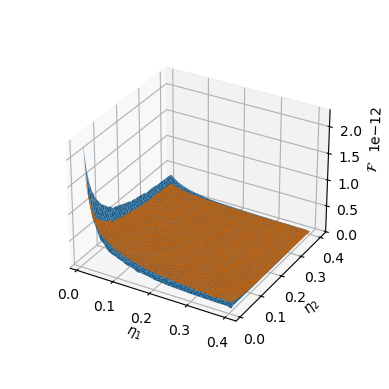

In [89]:
targeteddata1 = QFIEs[0,0,:,:,:,0]
targeteddata2 = QFIEs[1,0,:,:,:,1]
maximized1 = sp.signal.wiener(np.nanmax(targeteddata1,axis=2))
maximized2 = sp.signal.wiener(np.nanmax(targeteddata2,axis=2))

[η1grid,η2grid] = np.meshgrid(η1vals,η2vals,indexing='ij')
select_not_huge = (η1grid<.8)*(η2grid<.8)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_trisurf(η1grid[select_not_huge],η2grid[select_not_huge],maximized1[select_not_huge])

ax.plot_trisurf(η1grid[select_not_huge],η2grid[select_not_huge],maximized2[select_not_huge])
ax.set_xlabel(r'$\eta_1$')
ax.set_ylabel(r'$\eta_2$')
ax.set_zlabel(r'$\mathcal{F}$')
ax.set_box_aspect(None, zoom=0.8)
plt.show()

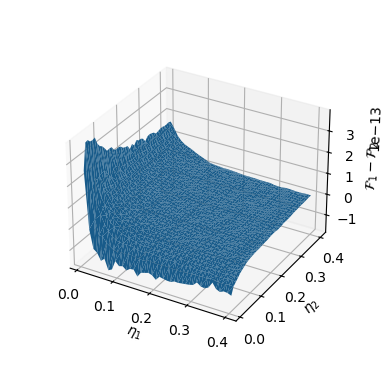

In [93]:
diff = maximized1-maximized2#sp.signal.wiener(maximized1,(10,10))-sp.signal.wiener(maximized2,(10,10))
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_trisurf(η1grid[select_not_huge],η2grid[select_not_huge],diff[select_not_huge])
ax.set_xlabel(r'$\eta_1$')
ax.set_ylabel(r'$\eta_2$')
ax.set_zlabel(r'$\mathcal{F}_1-\mathcal{F}_2$')
ax.set_box_aspect(None, zoom=0.8)
plt.show()

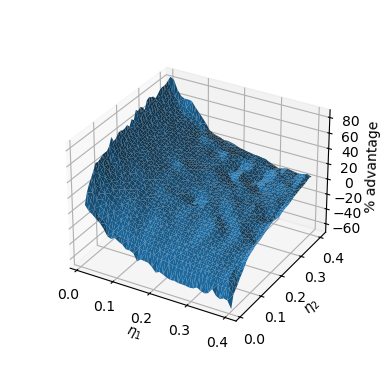

In [94]:
rel = 100*sp.signal.wiener(diff/maximized2)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_trisurf(η1grid[select_not_huge],η2grid[select_not_huge],rel[select_not_huge])
ax.set_xlabel(r'$\eta_1$')
ax.set_ylabel(r'$\eta_2$')
ax.set_zlabel(r'% advantage')
ax.set_box_aspect(None, zoom=0.8)
plt.show()

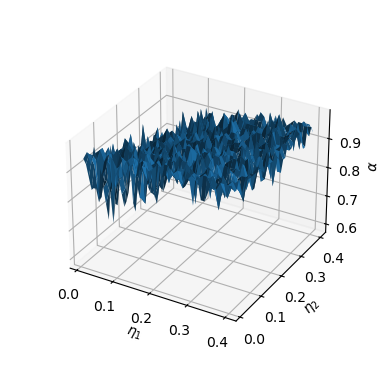

In [30]:
αmax = αvals[np.argmax(targeteddata1,axis=2)]
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,np.abs(αmax))
ax.set_xlabel(r'$\eta_1$')
ax.set_ylabel(r'$\eta_2$')
ax.set_zlabel(r'$\alpha$')
ax.set_box_aspect(None, zoom=0.8)
plt.show()

In [31]:
#r2max = np.array(r2vals)[np.argmax(np.nanmax(targeteddata,axis=2),axis=2)]
#fig = plt.figure()
#ax = fig.add_subplot(projection='3d')
#ax.plot_surface(η1grid,η2grid,np.log(r2max))
#plt.show()

In [32]:
#selector = r2max >0
#fig = plt.figure()
#ax = fig.add_subplot(projection='3d')
#ax.plot_trisurf(η1grid[selector],η2grid[selector],np.abs(αmax[selector]))
#plt.show()

In [33]:
σ3.subs(r2,0)

[[2*alpha**2*eta1*sinh(r)**2 + 2*nbar + 1, 0, -2*alpha*sqrt(eta1)*sqrt(eta2)*sqrt(1 - alpha**2)*sinh(r)**2, 0, -2*alpha*sqrt(eta1)*sinh(r)*cosh(r), 0], [0, 2*alpha**2*eta1*sinh(r)**2 + 2*nbar + 1, 0, -2*alpha*sqrt(eta1)*sqrt(eta2)*sqrt(1 - alpha**2)*sinh(r)**2, 0, 2*alpha*sqrt(eta1)*sinh(r)*cosh(r)], [-2*alpha*sqrt(eta1)*sqrt(eta2)*sqrt(1 - alpha**2)*sinh(r)**2, 0, -2*alpha**2*eta2*sinh(r)**2 + 2*eta2*sinh(r)**2 + 2*nbar + 1, 0, sqrt(eta2)*sqrt(1 - alpha**2)*sinh(2*r), 0], [0, -2*alpha*sqrt(eta1)*sqrt(eta2)*sqrt(1 - alpha**2)*sinh(r)**2, 0, -2*alpha**2*eta2*sinh(r)**2 + 2*eta2*sinh(r)**2 + 2*nbar + 1, 0, -sqrt(eta2)*sqrt(1 - alpha**2)*sinh(2*r)], [-2*alpha*sqrt(eta1)*sinh(r)*cosh(r), 0, sqrt(eta2)*sqrt(1 - alpha**2)*sinh(2*r), 0, cosh(2*r), 0], [0, 2*alpha*sqrt(eta1)*sinh(r)*cosh(r), 0, -sqrt(eta2)*sqrt(1 - alpha**2)*sinh(2*r), 0, cosh(2*r)]]

In [34]:
(X2@X2)

matrix([[1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, sinh(r2)**2 + cosh(r2)**2, 0, 2*sinh(r2)*cosh(r2), 0],
        [0, 0, 0, sinh(r2)**2 + cosh(r2)**2, 0, -2*sinh(r2)*cosh(r2)],
        [0, 0, 2*sinh(r2)*cosh(r2), 0, sinh(r2)**2 + cosh(r2)**2, 0],
        [0, 0, 0, -2*sinh(r2)*cosh(r2), 0, sinh(r2)**2 + cosh(r2)**2]],
       dtype=object)

In [35]:
η1vals

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 ])

In [36]:
η2val =np.argmax(np.max(maximized2,axis=0))

In [37]:
η1val = np.argmax(np.max(maximized2,axis=1))

In [38]:
αval = np.argmax(QFIEs[1,0,η1val,η2val,:,1])

In [39]:
σbad = σ(rvals[1],nbarvals[0],η1vals[η1val],η2vals[η2val],αvals[αval],r2vals[1])

In [40]:
σbad

array([[ 1.02000000e+00,  0.00000000e+00,  1.99622685e-16,
         0.00000000e+00,  2.06048248e-08,  0.00000000e+00],
       [ 0.00000000e+00,  1.02000000e+00,  0.00000000e+00,
         1.99622685e-16,  0.00000000e+00, -2.06048248e-08],
       [ 1.99622685e-16,  0.00000000e+00,  1.02000000e+00,
         0.00000000e+00,  1.93763050e-08,  0.00000000e+00],
       [ 0.00000000e+00,  1.99622685e-16,  0.00000000e+00,
         1.02000000e+00,  0.00000000e+00, -1.93763050e-08],
       [ 2.06048248e-08,  0.00000000e+00,  1.93763050e-08,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -2.06048248e-08,  0.00000000e+00,
        -1.93763050e-08,  0.00000000e+00,  1.00000000e+00]])

In [41]:
dσsbad = [dσ(rvals[1],nbarvals[0],η1vals[η1val],η2vals[η2val],αvals[αval],r2vals[1]) for dσ in dσs]

In [42]:
FIMbad = FIM(σbad,dσsbad)

In [43]:
vec_QFIEs(FIMbad,target)

  0%|          | 0/1.0 [00:00<?, ?it/s]

np.float64(1.972733406980585e-12)

In [44]:
FIMbad

array([[2.11270720e-12, 9.66638198e-15],
       [9.66638198e-15, 1.86716777e-12]])

In [45]:
(rvals[1],nbarvals[0],η1vals[η1val],η2vals[η2val],αvals[αval],r2vals[1])

(np.float64(1.4142135623730925e-07),
 0.01,
 np.float64(0.01),
 np.float64(0.01),
 np.float64(-0.7284905660377359),
 0)

In [46]:
sp.linalg.pinvh([[4.60203408e-21, 2.62928100e-17],
 [2.62928100e-17, 1.50218762e-13]],rtol=1e-30)

array([[ 3.35062264e+28, -5.86459929e+24],
       [-5.86459929e+24,  1.02648161e+21]])

In [47]:
sp.linalg.inv([[4.60203408e-21, 2.62928100e-17],
 [2.62928100e-17, 1.50218762e-13]])

/tmp/ipykernel_1405265/2667518357.py:1: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9860870557956703e-16.
  sp.linalg.inv([[4.60203408e-21, 2.62928100e-17],


array([[ 3.35062269e+28, -5.86459937e+24],
       [-5.86459937e+24,  1.02648162e+21]])

In [48]:
B = [[1/target,0],[-np.sqrt(1-target**2)/target,1]]

In [49]:
toinv = B@FIMbad@np.transpose(B)

In [50]:
sp.linalg.inv(toinv)

array([[5.06910866e+11, 3.80447265e+11],
       [3.80447265e+11, 5.35583199e+11]])

In [51]:
sp.linalg.pinvh(toinv)

array([[5.06910866e+11, 3.80447265e+11],
       [3.80447265e+11, 5.35583199e+11]])

In [52]:
select_not_huge.shape

(40, 40)

In [53]:
maximized2[select_not_huge].shape

(1600,)

In [54]:
maximized2.shape

(40, 40)

In [55]:
np.sum(select_not_huge)

np.int64(1600)